In [32]:
# Practice 1

In [33]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [34]:
# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Class names
class_names = [
    "T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
]

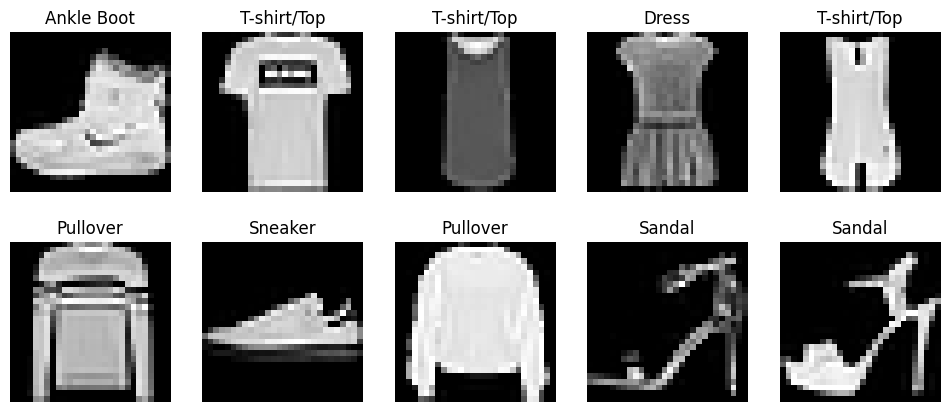

In [35]:
# Visualize 10 sample images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.show()

In [36]:
# Normalize the dataset
x_train = x_train / 255.0
x_test = x_test / 255.0

In [37]:
# Reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [38]:
# Practice 2

In [39]:
# Build CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [40]:
# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [41]:
# Train model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.8549 - loss: 0.4075 - val_accuracy: 0.8806 - val_loss: 0.3351
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9013 - loss: 0.2731 - val_accuracy: 0.8935 - val_loss: 0.2847
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9156 - loss: 0.2275 - val_accuracy: 0.9031 - val_loss: 0.2647
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9282 - loss: 0.1962 - val_accuracy: 0.9103 - val_loss: 0.2582
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9371 - loss: 0.1689 - val_accuracy: 0.9024 - val_loss: 0.2714
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9466 - loss: 0.1428 - val_accuracy: 0.9112 - val_loss: 0.2661
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9542 - loss: 0.1222 - val_accuracy: 0.9074 - val_loss: 0.2779
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9614 -

In [42]:
# Practice 3

In [43]:
# Training Accuracy
train_loss, train_accuracy = model.evaluate(x_train, y_train, verbose=0)

In [44]:
# Test Accuracy and Loss
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

Training Accuracy: 0.975350022315979
Test Accuracy: 0.9093000292778015
Test Loss: 0.34555768966674805


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


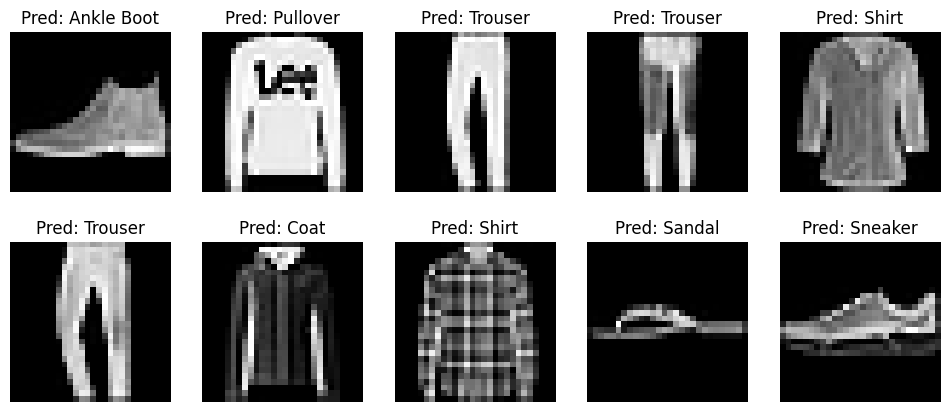

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Predictions on sample images
predictions = model.predict(x_test[:10])

plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title(f"Pred: {class_names[np.argmax(predictions[i])]}")
    plt.axis("off")
plt.show()